In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os, tqdm, glob
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.49'
import numpy as np
import matplotlib.pyplot as plt
from functools import partial

import jax
import jax.numpy as jnp
import jax_cosmo as jc

import optax
from flax import nnx
import orbax.checkpoint as ocp

import diffrax
from diffrax import diffeqsolve, ODETerm, Dopri5, LeapfrogMidpoint, PIDController, SaveAt, ConstantStepSize
from jax.experimental.ode import odeint

import jaxpm
from jaxpm.painting import cic_paint, cic_read
from jaxpm.pm import linear_field, lpt, make_ode_fn, pm_forces, make_ode_fn_diffrax, make_ode_fn
from jaxpm.kernels import fftk, gradient_kernel, invlaplace_kernel, longrange_kernel, invnabla_kernel
from jaxpm import camels, plotting, hpm, pm, nn

jax.devices("gpu")

[cuda(id=0)]

In [3]:
mesh_per_dim = 64
mesh_shape = [mesh_per_dim] * 3

In [4]:
CV = "CV_0"
i_snapshots = range(1, 33+8, 8)
# i_snapshots = None

In [5]:
vcic_paint = jax.vmap(cic_paint, in_axes=(None, 0))

# CAMELS

In [6]:
nbody_dict = camels.load_CV_snapshots(
    "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG_DM/CV/" + CV,
    mesh_per_dim,
    parts_per_dim=None,
    i_snapshots=i_snapshots,
    return_hydro=False
)

cosmo = nbody_dict["cosmo"]
scales = nbody_dict["scales"]

n_dm_poss = nbody_dict["dm_poss"]
n_dm_vels = nbody_dict["dm_vels"]

Using snapshots ['/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG_DM/CV/CV_0/snapshot_018.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG_DM/CV/CV_0/snapshot_042.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG_DM/CV/CV_0/snapshot_058.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG_DM/CV/CV_0/snapshot_074.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG_DM/CV/CV_0/snapshot_090.hdf5']
Using all particles


loading snapshots: 100%|██████████| 5/5 [00:03<00:00,  1.54it/s]


In [7]:
hydro_dict = camels.load_CV_snapshots(
    "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/" + CV,
    mesh_per_dim,
    parts_per_dim=None,
    i_snapshots=i_snapshots,
    return_hydro=True,
)

h_cosmo = hydro_dict["cosmo"]
h_scales = hydro_dict["scales"]

h_dm_poss = hydro_dict["dm_poss"]
h_dm_vels = hydro_dict["dm_vels"]
h_gas_poss = hydro_dict["gas_poss"]
h_gas_vels = hydro_dict["gas_vels"]

h_dm_mass = cosmo.Omega_c / (cosmo.Omega_c + cosmo.Omega_b)
h_gas_mass = cosmo.Omega_b / (cosmo.Omega_c + cosmo.Omega_b)

Using snapshots ['/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_018.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_042.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_058.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_074.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_090.hdf5']
Using all particles


loading snapshots: 100%|██████████| 5/5 [00:32<00:00,  6.42s/it]


# plots

In [11]:
n_dm_poss[0].shape

(16777216, 3)

In [12]:
jnp.zeros(mesh_shape).shape

(64, 64, 64)

In [13]:
cic_paint(jnp.zeros(mesh_shape), n_dm_poss[0])

2025-03-03 18:36:34.681978: W external/tsl/tsl/framework/bfc_allocator.cc:482] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.50GiB (rounded to 1610612736)requested by op 
2025-03-03 18:36:34.682170: W external/tsl/tsl/framework/bfc_allocator.cc:494] ****************************************************************________***************************_
E0303 18:36:34.682238 3751703 pjrt_stream_executor_client.cc:2826] Execution of replica 0 failed: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 1610612736 bytes.
BufferAssignment OOM Debugging.
BufferAssignment stats:
             parameter allocation:  192.00MiB
              constant allocation:         0B
        maybe_live_out allocation:    1.50GiB
     preallocated temp allocation:         0B
                 total allocation:    1.69GiB
              total fragmentation:         0B (0.00%)
Peak buffers:
	Buffer 1:
		Size: 1.50GiB
		Operator: op_name="jit(add)/jit(main)/add" source_file="/cluster/home/athoms

ValueError: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 1610612736 bytes.
BufferAssignment OOM Debugging.
BufferAssignment stats:
             parameter allocation:  192.00MiB
              constant allocation:         0B
        maybe_live_out allocation:    1.50GiB
     preallocated temp allocation:         0B
                 total allocation:    1.69GiB
              total fragmentation:         0B (0.00%)
Peak buffers:
	Buffer 1:
		Size: 1.50GiB
		Operator: op_name="jit(add)/jit(main)/add" source_file="/cluster/home/athomsen/flatiron/repos/JaxPM/jaxpm/painting.py" source_line=30
		XLA Label: fusion
		Shape: f32[16777216,8,3]
		==========================

	Buffer 2:
		Size: 192.00MiB
		Entry Parameter Subshape: f32[16777216,1,3]
		==========================

	Buffer 3:
		Size: 96B
		Entry Parameter Subshape: s32[1,8,3]
		==========================



In [10]:
# nbody
for i in range(len(scales)):
    n_N_dm = cic_paint(jnp.zeros(mesh_shape), n_dm_poss[i])
    # n_rho_dm = n_N_dm


2025-03-03 18:35:25.457900: W external/tsl/tsl/framework/bfc_allocator.cc:482] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.50GiB (rounded to 1610612736)requested by op 
2025-03-03 18:35:25.458091: W external/tsl/tsl/framework/bfc_allocator.cc:494] ************************************************************____________***************************_
E0303 18:35:25.458155 3751703 pjrt_stream_executor_client.cc:2826] Execution of replica 0 failed: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 1610612736 bytes.
BufferAssignment OOM Debugging.
BufferAssignment stats:
             parameter allocation:    1.50GiB
              constant allocation:         0B
        maybe_live_out allocation:    1.50GiB
     preallocated temp allocation:         0B
                 total allocation:    3.00GiB
              total fragmentation:         0B (0.00%)
Peak buffers:
	Buffer 1:
		Size: 1.50GiB
		Entry Parameter Subshape: f32[16777216,8,3]

	Buffer 2:
		Size: 1.50GiB
		Op

XlaRuntimeError: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 1610612736 bytes.
BufferAssignment OOM Debugging.
BufferAssignment stats:
             parameter allocation:    1.50GiB
              constant allocation:         0B
        maybe_live_out allocation:    1.50GiB
     preallocated temp allocation:         0B
                 total allocation:    3.00GiB
              total fragmentation:         0B (0.00%)
Peak buffers:
	Buffer 1:
		Size: 1.50GiB
		Entry Parameter Subshape: f32[16777216,8,3]
		==========================

	Buffer 2:
		Size: 1.50GiB
		Operator: op_name="jit(absolute)/jit(main)/abs" source_file="/cluster/home/athomsen/flatiron/repos/JaxPM/jaxpm/painting.py" source_line=31
		XLA Label: fusion
		Shape: f32[16777216,8,3]
		==========================



In [9]:
vcic_paint = jax.vmap(cic_paint, in_axes=(None, 0))

# nbody
n_N_dm = vcic_paint(jnp.zeros(mesh_shape), n_dm_poss)
n_rho_dm = n_N_dm

# # hydro
# h_dm_mass = cosmo.Omega_c / (cosmo.Omega_c + cosmo.Omega_b)
# h_gas_mass = cosmo.Omega_b / (cosmo.Omega_c + cosmo.Omega_b)

# h_N_dm = vcic_paint(jnp.zeros(mesh_shape), h_dm_poss)
# h_N_gas = vcic_paint(jnp.zeros(mesh_shape), h_gas_poss)

# h_rho_dm = h_dm_mass * h_N_dm
# h_rho_gas = h_gas_mass * h_N_gas

# h_rho_tot = h_rho_dm + h_rho_gas

# plotting.compare_field_evolution(
#     scales, 
#     jnp.stack([n_rho_dm, h_rho_tot], axis=0),
#     title="CAMELS",
#     col_titles=["total matter \n(CAMELS, nbody)", "total matter \n(CAMELS, hydro)"],
#     include_pk=True,
#     include_reference=True,
# )

# print(jnp.sum(n_rho_dm))
# print(jnp.sum(h_rho_tot))

2025-03-03 18:34:16.787955: W external/xla/xla/service/hlo_rematerialization.cc:2948] Can't reduce memory use below 2.99GiB (3210635254 bytes) by rematerialization; only reduced to 7.50GiB (8053063776 bytes), down from 7.50GiB (8053063776 bytes) originally
2025-03-03 18:34:26.812353: W external/tsl/tsl/framework/bfc_allocator.cc:482] Allocator (GPU_0_bfc) ran out of memory trying to allocate 7.50GiB (rounded to 8053063680)requested by op 
2025-03-03 18:34:26.812535: W external/tsl/tsl/framework/bfc_allocator.cc:494] **********************************______________________________________************************____
E0303 18:34:26.812616 3751703 pjrt_stream_executor_client.cc:2826] Execution of replica 0 failed: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 8053063680 bytes.
BufferAssignment OOM Debugging.
BufferAssignment stats:
             parameter allocation:  960.00MiB
              constant allocation:         0B
        maybe_live_out allocation:    7.50GiB
     pre

XlaRuntimeError: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 8053063680 bytes.
BufferAssignment OOM Debugging.
BufferAssignment stats:
             parameter allocation:  960.00MiB
              constant allocation:         0B
        maybe_live_out allocation:    7.50GiB
     preallocated temp allocation:        96B
  preallocated temp fragmentation:         0B (0.00%)
                 total allocation:    8.44GiB
              total fragmentation:         0B (0.00%)
Peak buffers:
	Buffer 1:
		Size: 7.50GiB
		Operator: op_name="jit(add)/jit(main)/add" source_file="/cluster/home/athomsen/flatiron/repos/JaxPM/jaxpm/painting.py" source_line=30
		XLA Label: fusion
		Shape: f32[5,16777216,8,3]
		==========================

	Buffer 2:
		Size: 960.00MiB
		Entry Parameter Subshape: f32[5,16777216,1,3]
		==========================

	Buffer 3:
		Size: 96B
		Operator: op_name="jit(add)/jit(main)/convert_element_type[new_dtype=float32 weak_type=False]" source_file="/cluster/home/at

# old

100%|██████████| 5/5 [00:06<00:00,  1.35s/it]


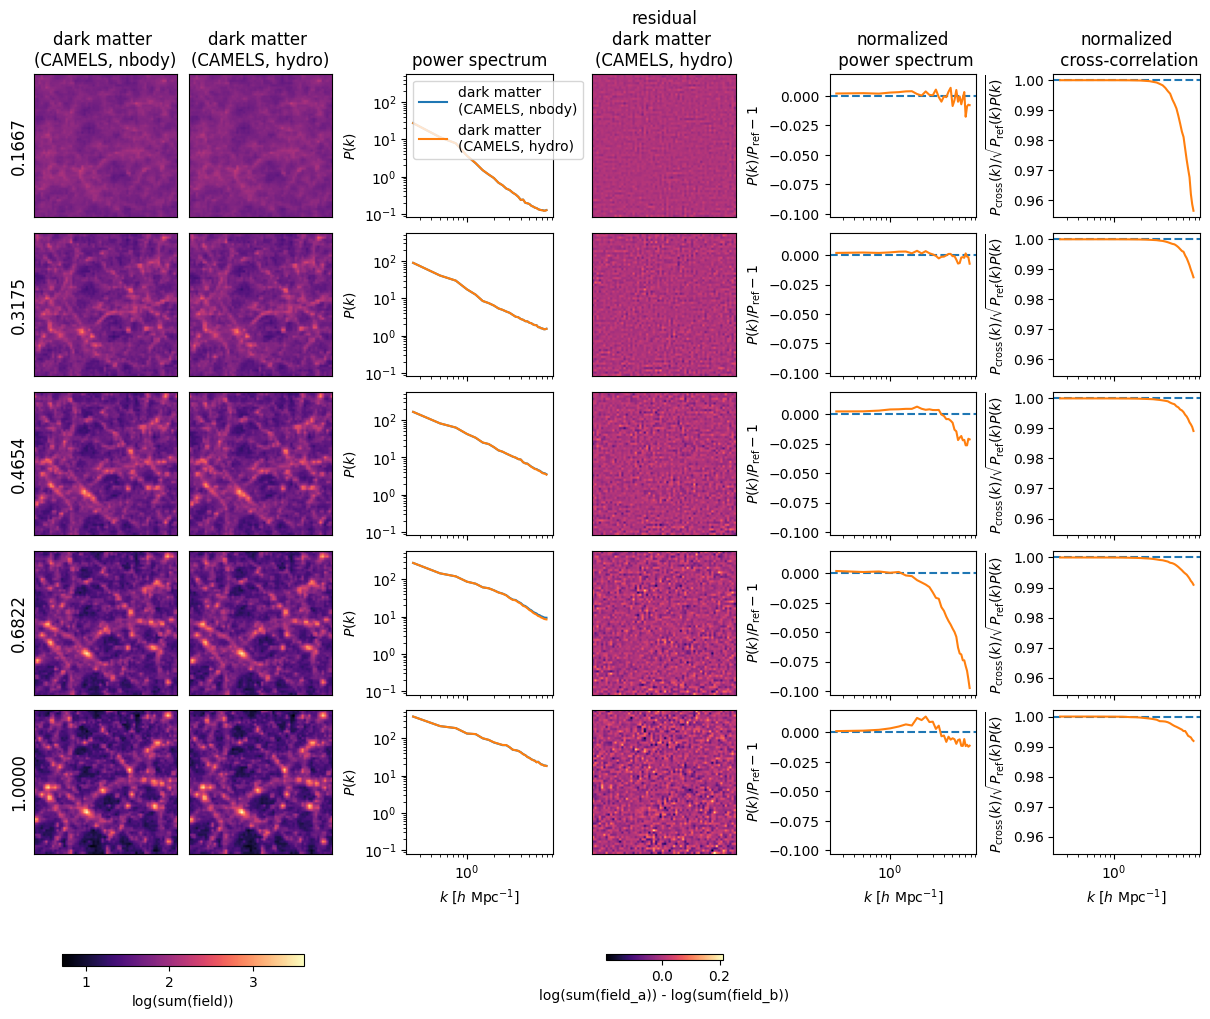

In [8]:
plotting.compare_particle_evolution(
    mesh_shape,
    scales,
    jnp.stack([n_dm_poss, h_dm_poss], axis=0),
    include_pk=True,
    include_reference=True,
    # values
    shared_colorbar=True,
    # cosmetics
    title=None,
    col_titles=["dark matter \n(CAMELS, nbody)", "dark matter \n(CAMELS, hydro)"],
)

In [12]:
# vcic_paint = jax.vmap(cic_paint, in_axes=(None, 0))

# # nbody
# n_N_dm = vcic_paint(jnp.zeros(mesh_shape), n_dm_poss)
# n_rho_dm = n_N_dm

# # hydro
# h_dm_mass = cosmo.Omega_c / (cosmo.Omega_c + cosmo.Omega_b)
# h_gas_mass = cosmo.Omega_b / (cosmo.Omega_c + cosmo.Omega_b)

# h_N_dm = vcic_paint(jnp.zeros(mesh_shape), h_dm_poss)
# h_N_gas = vcic_paint(jnp.zeros(mesh_shape), h_gas_poss)

# h_rho_dm = h_dm_mass * h_N_dm
# h_rho_gas = h_gas_mass * h_N_gas

# h_rho_tot = h_rho_dm + h_rho_gas

# plotting.compare_field_evolution(
#     scales, 
#     jnp.stack([n_N_dm, h_N_dm], axis=0),
#     title="CAMELS",
#     col_titles=["dark matter \n(CAMELS, nbody)", "dark matter \n(CAMELS, hydro)"],
#     include_pk=True,
#     include_reference=True,
# )

100%|██████████| 5/5 [00:06<00:00,  1.24s/it]


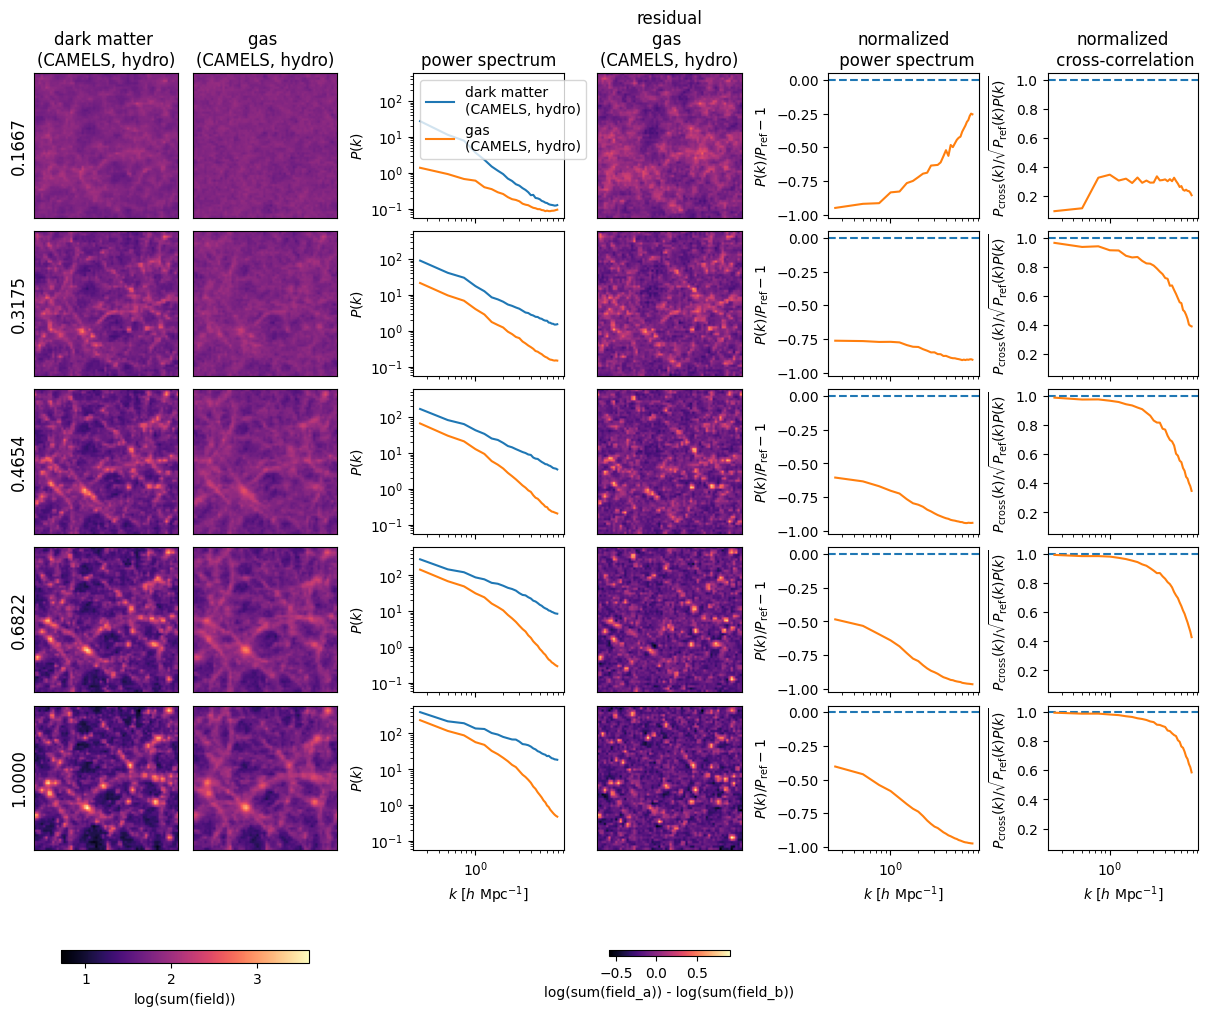

In [10]:
plotting.compare_particle_evolution(
    mesh_shape,
    scales,
    jnp.stack([h_dm_poss, h_gas_poss], axis=0),
    include_pk=True,
    include_reference=True,
    # values
    shared_colorbar=True,
    # cosmetics
    title=None,
    col_titles=["dark matter \n(CAMELS, hydro)", "gas \n(CAMELS, hydro)"],
)

100%|██████████| 5/5 [00:06<00:00,  1.26s/it]


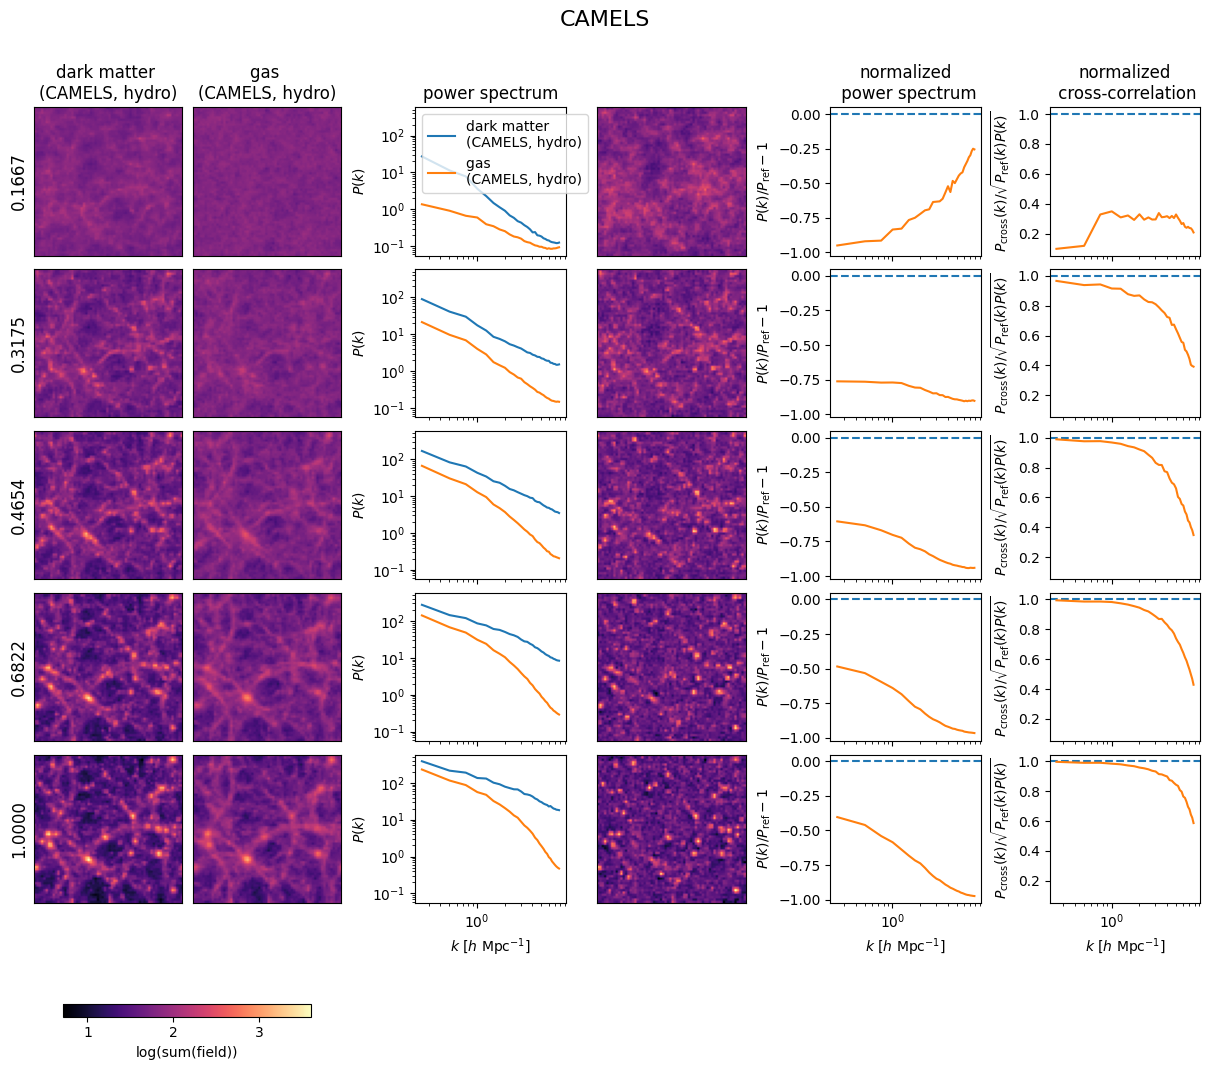

In [25]:
vcic_paint = jax.vmap(cic_paint, in_axes=(None, 0))

# hydro
h_dm_mass = cosmo.Omega_c / (cosmo.Omega_c + cosmo.Omega_b)
h_gas_mass = cosmo.Omega_b / (cosmo.Omega_c + cosmo.Omega_b)

h_N_dm = vcic_paint(jnp.zeros(mesh_shape), h_dm_poss)
h_N_gas = vcic_paint(jnp.zeros(mesh_shape), h_gas_poss)

# h_rho_dm = h_dm_mass * h_N_dm
# h_rho_gas = h_gas_mass * h_N_gas

# h_rho_dm = (1 - h_dm_mass) * h_N_dm
# h_rho_gas = (1 - h_gas_mass) * h_N_gas

h_rho_dm = h_N_dm
h_rho_gas = h_N_gas

plotting.compare_field_evolution(
    scales, 
    jnp.stack([h_rho_dm, h_rho_gas], axis=0),
    title="CAMELS",
    col_titles=["dark matter \n(CAMELS, hydro)", "gas \n(CAMELS, hydro)"],
    include_pk=True,
    include_reference=True,
)

100%|██████████| 5/5 [00:06<00:00,  1.25s/it]


1310720.0
1310720.0


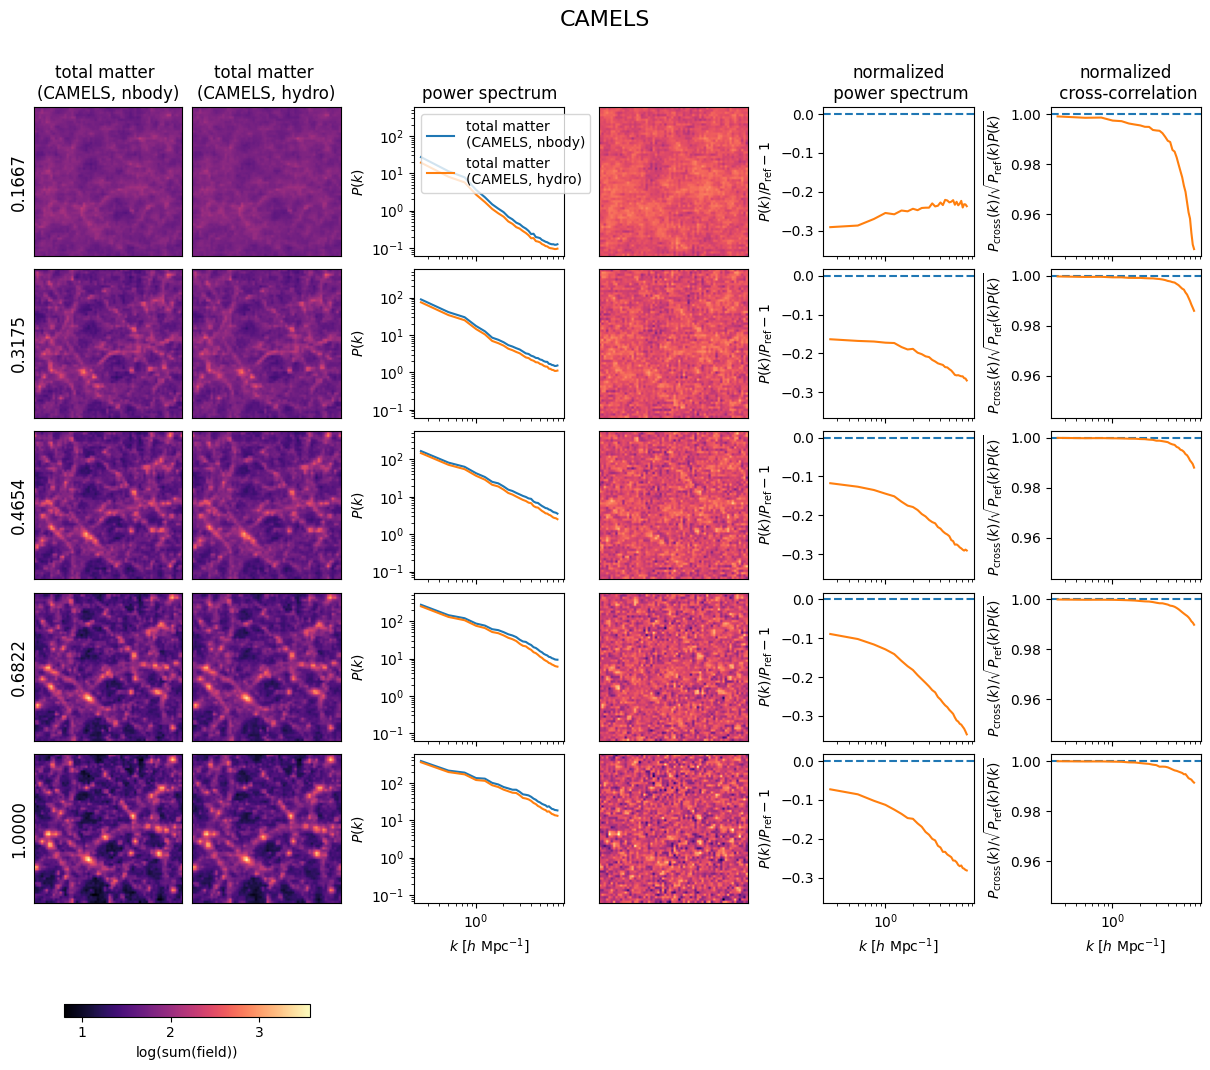

In [21]:
vcic_paint = jax.vmap(cic_paint, in_axes=(None, 0))

# nbody
n_N_dm = vcic_paint(jnp.zeros(mesh_shape), n_dm_poss)
n_rho_dm = n_N_dm

# hydro
h_dm_mass = cosmo.Omega_c / (cosmo.Omega_c + cosmo.Omega_b)
h_gas_mass = cosmo.Omega_b / (cosmo.Omega_c + cosmo.Omega_b)

h_N_dm = vcic_paint(jnp.zeros(mesh_shape), h_dm_poss)
h_N_gas = vcic_paint(jnp.zeros(mesh_shape), h_gas_poss)

h_rho_dm = h_dm_mass * h_N_dm
h_rho_gas = h_gas_mass * h_N_gas

h_rho_tot = h_rho_dm + h_rho_gas

plotting.compare_field_evolution(
    scales, 
    jnp.stack([n_rho_dm, h_rho_tot], axis=0),
    title="CAMELS",
    col_titles=["total matter \n(CAMELS, nbody)", "total matter \n(CAMELS, hydro)"],
    include_pk=True,
    include_reference=True,
)

print(jnp.sum(n_rho_dm))
print(jnp.sum(h_rho_tot))

100%|██████████| 5/5 [00:06<00:00,  1.23s/it]


1310720.0
1313425.2


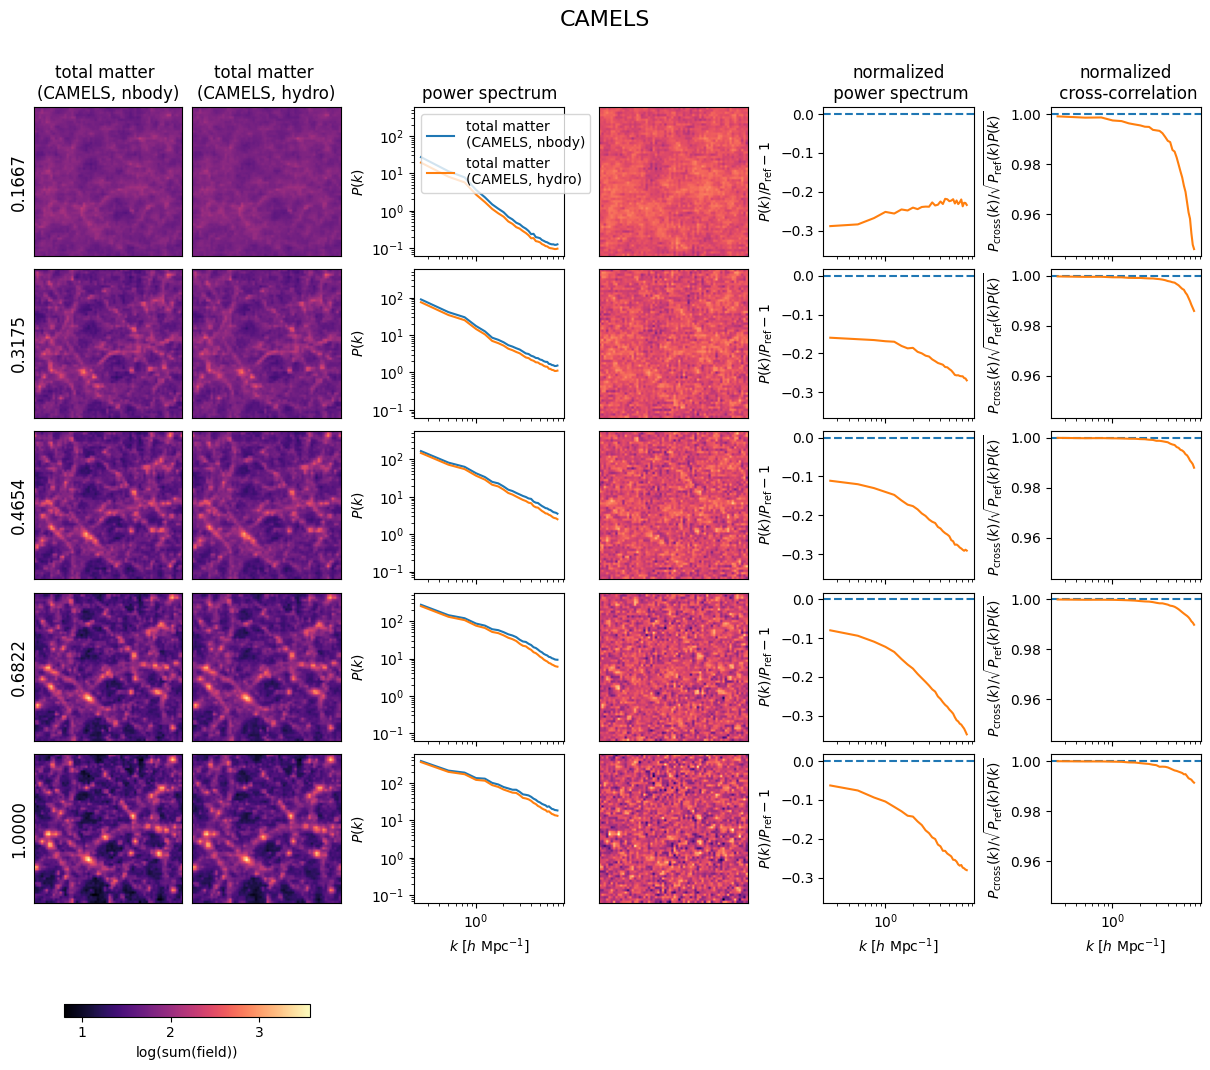

In [22]:
vcic_paint = jax.vmap(cic_paint, in_axes=(None, 0))

# nbody
n_N_dm = vcic_paint(jnp.zeros(mesh_shape), n_dm_poss)
n_rho_dm = n_N_dm

# hydro
h_dm_mass = cosmo.Omega_c / (cosmo.Omega_c + cosmo.Omega_b)
h_gas_mass = hydro_dict["gas_masss"]

h_N_dm = vcic_paint(jnp.zeros(mesh_shape), h_dm_poss)

h_rho_dm = h_dm_mass * h_N_dm
h_rho_gas = jax.vmap(cic_paint, in_axes=(None, 0, 0))(jnp.zeros(mesh_shape), h_gas_poss, h_gas_mass)

h_rho_tot = h_rho_dm + h_rho_gas

plotting.compare_field_evolution(
    scales, 
    jnp.stack([n_rho_dm, h_rho_tot], axis=0),
    title="CAMELS",
    col_titles=["total matter \n(CAMELS, nbody)", "total matter \n(CAMELS, hydro)"],
    include_pk=True,
    include_reference=True,
)

print(jnp.sum(n_rho_dm))
print(jnp.sum(h_rho_tot))

In [26]:
z = 1/scales - 1

In [27]:
z

Array([5.       , 2.1496084, 1.1486764, 0.4658364, 0.       ], dtype=float32)